In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from statsmodels.stats.outliers_influence import variance_inflation_factor

import lightgbm as lgb
import numpy as np
import optuna
import xgboost as xgb
from sklearn.metrics import  f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight



In [106]:
df = pd.read_csv("ai_student_impact_dataset.csv")
y = df["Burnout_Risk_Level"]
X = df.drop(columns="Burnout_Risk_Level")


In [76]:
X.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


- **Weekly_GenAI_Hours**  differenza tra la media (8.4) e la mediana (5.8) comportamento asimmetrico con coda a destra
- **Traditional_Study_Hours**  Media ~11.2 ore, std (deviazione standard) ~5.15 ore
- **Post_Semester_GPA - Pre_Semester_GPA** è registrato un moglioramento del rendimento

In [107]:
# Calcola le percentuali (normalize=True restituisce valori tra 0 e 1, poi moltiplichiamo per 100)
percentuali_burnout = y.value_counts(normalize=True) * 100

print("Percentuale per ogni livello di Burnout:")
print(percentuali_burnout)


Percentuale per ogni livello di Burnout:
Burnout_Risk_Level
Medium    42.288
Low       32.738
High      24.974
Name: proportion, dtype: float64


- il dataset è un po' sbilanciato ma poteva andare peggio

In [78]:
X.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00


In [108]:

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,          # 80-20
    random_state=42,        
    stratify=y              # le stesse proporzioni delle classi del target sia in train che in test
)

target_map = {'Low': 0, 'Medium': 1, 'High': 2}   # random forest e xgboost lavorano meglio se y è mappata
y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

# gestisco le colonne 

In [109]:
X_train.drop(columns=['Student_ID'], inplace=True, errors='ignore')
X_test.drop(columns=['Student_ID'], inplace=True, errors='ignore') # colonna inutile


In [110]:
#                     SOLUZIONE MIGLIORE DEL pd.get_dummies()


#TUTTE le colonne su cui voglio fare il One-Hot Encoding. (Solo con pochi valori ciascuno)
colonne_categoriche = [
    'Major_Category', 
    'Primary_Use_Case', 
    'Prompt_Engineering_Skill',
    'Institutional_Policy'
]
# 1. Definizione di trasformatore
# 'remainder="passthrough"' dice di lasciare intatte tutte le altre colonne
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot_multiclasse', OneHotEncoder(drop='first', sparse_output=False), colonne_categoriche)
    ],
    remainder='passthrough' ,# Lascia intatte le colonne numeriche
    verbose_feature_names_out=False # mi permette di eliminare onehot_multiclasse__ e remainder__ dai nomi delle colonne
)

# restituisce un DataFrame Pandas (mantenendo i nomi delle colonne)
preprocessor.set_output(transform="pandas")

# 2. Alleniamo il trasformatore sul Train ed eseguiamo la trasformazione su entrambi
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("One-Hot Encoding completato !")

One-Hot Encoding completato !


- calcolo il VIF 

In [111]:
regola_cose = {'Freshman' : 1, 'Sophomore': 2,'Junior': 3, 'Senior' : 4,  'Graduate':5}

# Applica la mappatura sia a y_train che a y_test 
X_train['Year_of_Study']  = X_train['Year_of_Study'].map(regola_cose)
X_test['Year_of_Study']  = X_test['Year_of_Study'].map(regola_cose)

In [112]:
X_numeriche = X_train.select_dtypes(include=['int64', 'float64']).copy()

# Aggiungiamo una colonna di costanti (richiesta matematicamente dal calcolo del VIF)
X_numeriche['Intercept'] = 1

# 2. Creiamo un DataFrame per contenere i risultati del VIF
vif_data = pd.DataFrame()
vif_data["Caratteristica"] = X_numeriche.columns

# 3. Calcoliamo il VIF per ogni colonna
vif_data["VIF"] = [
    variance_inflation_factor(X_numeriche.values, i) 
    for i in range(X_numeriche.shape[1])
]

# Rimuoviamo la riga dell'intercetta che non ci interessa analizzare
vif_data = vif_data[vif_data['Caratteristica'] != 'Intercept']

# Ordiniamo i risultati dal VIF più alto a quello più basso
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("--- ANALISI DELLA MULTICOLLINEARITÀ (VIF) ---")
print(vif_data.round(2))

--- ANALISI DELLA MULTICOLLINEARITÀ (VIF) ---
                                Caratteristica   VIF
0                            Post_Semester_GPA  9.52
1                             Pre_Semester_GPA  9.16
2                          Major_Category_STEM  2.79
3                      Major_Category_Business  2.56
4            Prompt_Engineering_Skill_Beginner  2.53
5                    Major_Category_Humanities  2.17
6                       Major_Category_Medical  1.97
7   Primary_Use_Case_Debugging/Troubleshooting  1.89
8                           Weekly_GenAI_Hours  1.88
9                      Perceived_AI_Dependency  1.86
10       Prompt_Engineering_Skill_Intermediate  1.79
11                   Primary_Use_Case_Ideation  1.76
12        Primary_Use_Case_Summarizing_Reading  1.62
13                              Tool_Diversity  1.57
14   Primary_Use_Case_Direct_Answer_Generation  1.43
15             Institutional_Policy_Strict_Ban  1.36
16  Institutional_Policy_Allowed_With_Citation  1.33


ATTENZIONE al VIF 
- Post_Semester_GPA  9 circa
- Pre_Semester_GPA  9 circa
valuto come cambia la vif se elimino una delle due colonne:
- Pre_Semester_GPA  1 circa

il vif mi fa capire che le due colonne portano con se quasi le stesse informazioni però dal momento che gli alberi di decisione operano ricercando legami non lineari scelgo di lasciare Pre_Semester_GPA

In [84]:

X_test.info()   # Perceived_AI_Dependency- Tool_Diversity    /     Institutional_Policy  ( **dove è bannata** prodotto di ore ai - Anxiety_Level_During_Exams - Paid_Subscription )  / 

<class 'pandas.DataFrame'>
Index: 10000 entries, 18437 to 43395
Data columns (total 22 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Major_Category_Business                     10000 non-null  float64
 1   Major_Category_Humanities                   10000 non-null  float64
 2   Major_Category_Medical                      10000 non-null  float64
 3   Major_Category_STEM                         10000 non-null  float64
 4   Primary_Use_Case_Debugging/Troubleshooting  10000 non-null  float64
 5   Primary_Use_Case_Direct_Answer_Generation   10000 non-null  float64
 6   Primary_Use_Case_Ideation                   10000 non-null  float64
 7   Primary_Use_Case_Summarizing_Reading        10000 non-null  float64
 8   Prompt_Engineering_Skill_Beginner           10000 non-null  float64
 9   Prompt_Engineering_Skill_Intermediate       10000 non-null  float64
 10  Institutional_Policy_A

In [85]:
X_test.describe()

,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,...,Institutional_Policy_Strict_Ban,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.250100,0.197900,0.127900,0.301100,0.241700,0.127800,0.215300,0.178000,0.369200,0.359600,...,0.191900,2.881100,3.143922,8.379751,2.788500,11.169969,3.490800,4.276000,3.346239,75.950446
std,0.433092,0.398436,0.333995,0.458759,0.428135,0.333884,0.411051,0.382532,0.482612,0.479907,...,0.393815,1.360275,0.481361,8.174937,1.191684,5.150600,1.815005,2.152182,0.498241,13.254755
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.183000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2.000000,2.830000,2.390000,2.000000,7.510000,2.000000,3.000000,3.021000,67.200000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,3.000000,3.202500,5.870000,3.000000,11.090000,3.000000,4.000000,3.411000,76.140000
75%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,4.000000,3.524000,11.660000,4.000000,14.670000,5.000000,6.000000,3.751000,85.252500
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,3.987000,40.000000,5.000000,29.950000,10.000000,10.000000,4.000000,100.000000


scelgo di fare target encoding sulla colonna "Year_of_Study", in funzione delle osservazioni in fase di analisi data.
RECAP da analisi dati:
I Freshman (1) iniziano con un livello di burnout alto (il rosso sfiora il 28%). Questo è fisiologico e descrive lo shock da inserimento universitario, le prime sessioni d'esame e il cambio di metodo di studio.

Nei Sophomore (2) e ancora di più nei Junior (3), la fascia rossa si restringe visibilmente, toccando il punto più basso (sotto il 20%). Parallelamente, nei Junior la fascia verde (Low) raggiunge la sua massima espansione (oltre il 40%).

La fascia rossa (High) torna a espandersi, superando nuovamente il 20%.

# valutazione con la PCA

In [115]:

# 1. La PCA è sensibile alle scale, quindi standardizziamo prima le feature
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Inizializziamo la PCA chiedendo di mantenere, ad esempio, solo 3 componenti principali
pca = PCA(n_components=10, random_state=42)

# 3. Trasformiamo i nostri dataset enormi in dataset compressi a 3 colonne
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# [Opzionale] Controlliamo quanta informazione abbiamo salvato
print(f"Informazione totale preservata: {sum(pca.explained_variance_ratio_):.2%}")


Informazione totale preservata: 71.93%


In [88]:

# # Poiché abbiamo un problema a 3 classi (Low, Medium, High), impostiamo l'objective corretto
# xgb_base = XGBClassifier(
#     objective='multi:softprob', 
#     random_state=42, 
#     use_label_encoder=False, 
#     eval_metric='mlogloss'
# )

# # 2. Definiamo la griglia degli iperparametri per XGBoost
# # Questa selezione è ottimizzata per trovare un buon bilanciamento senza andare in overfitting
# param_grid = {
#     'n_estimators': [100, 150],           # Numero di alberi sequenziali
#     'max_depth': [3, 5, 7],               # Profondità degli alberi (XGBoost preferisce alberi più bassi di RF)
#     'learning_rate': [0.01, 0.05, 0.1],    # Passo di apprendimento (regola l'impatto di ogni nuovo albero)
#     'subsample': [0.6 ,0.8],              # Percentuale di dati da campionare per ogni albero
#     'colsample_bytree': [0,4, 0.7]        # Percentuale di feature da campionare per ogni albero
# }

# # 3. Configuriama la Grid Search con 5-Fold Cross-Validation
# grid_search_xgb = GridSearchCV(
#     estimator=xgb_base,
#     param_grid=param_grid,
#     cv=5,                                 # Sdoppia il train in 5 parti per convalidare i punteggi
#     scoring='accuracy',                   # Puoi usare 'f1_macro' se le classi sono sbilanciate
#     n_jobs=-1,                            # Sfrutta tutti i core della CPU in parallelo
#     verbose=2                             # Mostra i log dell'avanzamento dei calcoli
# )

# # 4. Avviamo l'addestramento sui dati
# grid_search_xgb.fit(X_train, y_train)



# print("\n--- Risultati della Grid Search con XGBoost ---")
# print(f"Miglior Accuratezza in Cross-Validation: {grid_search_xgb.best_score_:.4f}")
# print("Migliori Iperparametri Trovati:")
# for param, value in grid_search_xgb.best_params_.items():
#     print(f"  -> {param}: {value}")

# # 5. Estraiamo il modello migliore e già pronto
# best_xgb_model = grid_search_xgb.best_estimator_


#                             già trovato i valori ottimi

In [116]:
best_xgb = XGBClassifier(
    objective='multi:softprob',     # Specifica che è un problema multi-classe probabilistico
    eval_metric='mlogloss',         # Metrica di valutazione interna
    colsample_bytree=0.7,           # Iperparametri ottimi trovati dalla tua Grid Search
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    subsample=0.6,
    random_state=42,                
    n_jobs=-1,           
)

best_xgb.fit(X_train, y_train)

y_pred_xgb = best_xgb.predict(X_test)

# Definizione dei nomi delle classi per rendere il report auto-esplicativo
target_names = ['Low (0)', 'Medium (1)', 'High (2)']

print(f"Accuratezza finale di XGBoost sul Test Set: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print("--- REPORT DI CLASSIFICAZIONE COMPLETO (XGBOOST) ---")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

Accuratezza finale di XGBoost sul Test Set: 0.5322

--- REPORT DI CLASSIFICAZIONE COMPLETO (XGBOOST) ---
              precision    recall  f1-score   support

     Low (0)       0.54      0.48      0.51      3274
  Medium (1)       0.48      0.61      0.54      4229
    High (2)       0.66      0.47      0.55      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



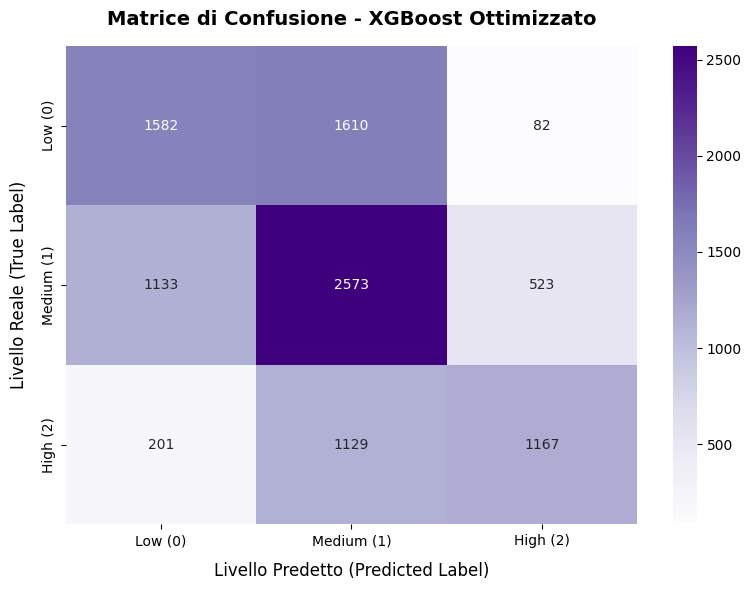

In [117]:
# 1. Calcoliamo la matrice di confusione numerica
# Specifichiamo labels=[0, 1, 2] per essere sicuri dell'ordine delle classi
matrice_xgb = confusion_matrix(y_test, y_pred_xgb, labels=[0, 1, 2])

# 2. Creiamo il grafico a mappa di calore (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrice_xgb, 
    annot=True,          # Mostra i numeri dentro i quadrati
    fmt='d',             # Formato numeri interi (discreti)
    cmap='Purples',      # Colore viola (molto in stile XGBoost!)
    xticklabels=['Low (0)', 'Medium (1)', 'High (2)'], 
    yticklabels=['Low (0)', 'Medium (1)', 'High (2)']
)

# 3. Personalizzazione dei titoli e delle etichette
plt.title('Matrice di Confusione - XGBoost Ottimizzato', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Livello Reale (True Label)', fontsize=12, labelpad=10)
plt.xlabel('Livello Predetto (Predicted Label)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

i risultati fanno schifo: 
**devo forzare qualcosa**

creo nuove colonne:
- stress_index (ore di ai)*(voto)
- abbonamento * stress da esame   
- ore di studio tradiz / ore ai  

In [118]:

def applica_feature_engineering(df):
   
    df_new = df.copy() # copia per sicurezza
    
    df_new['Study_to_AI_Ratio'] = df_new['Traditional_Study_Hours'] / (df_new['Weekly_GenAI_Hours'] + 1)
    
    # Un voto BASSO aumenti lo stress (es. 4.0 - GPA)
    gpa_inverso = 4.0 - df_new['Pre_Semester_GPA']   # scala GPA classica fino a 4.0.
    
    moltiplicatore_premium = df_new['Paid_Subscription'].apply(lambda x: 2.5 if x == 1 else 1.0)
    
    # Calcolo finale dello Stress Index
    # Moltiplichiamo: Ore AI * Ansia da Esame * Difficoltà del Voto * Peso Abbonamento
    df_new['Stress_Index'] = (
        df_new['Weekly_GenAI_Hours'] * df_new['Anxiety_Level_During_Exams'] * gpa_inverso * moltiplicatore_premium
    )

    df_new["Anxiety_by_Year"] = (
        df_new["Anxiety_Level_During_Exams"] * df_new["Year_of_Study"]
    )

    df_new["Study_Imbalance"] = np.abs(
        df_new["Traditional_Study_Hours"] - df_new["Weekly_GenAI_Hours"]
    )

    df_new["AI_Dependency_vs_Skill"] = (
        df_new["Perceived_AI_Dependency"] / (df_new["Skill_Retention_Score"] + 1e-5)
    )

    
    return df_new

# Applichiamo la funzione ai nostri dataset originari
X_train = applica_feature_engineering(X_train)
X_test = applica_feature_engineering(X_test)

print("Nuove colonne create con successo!")
print(X_train[['Study_to_AI_Ratio', 'Stress_Index',"Anxiety_by_Year", "Study_Imbalance","AI_Dependency_vs_Skill"]].head())

Nuove colonne create con successo!
       Study_to_AI_Ratio  Stress_Index  Anxiety_by_Year  Study_Imbalance  \
1497            0.692971     106.97280                9             3.63   
4233            3.869565       1.53120                2             8.92   
39113           0.884932      29.19420               35             0.16   
8818            7.951613       1.81056               16             9.62   
2082            1.502793      46.11000               16             5.50   

       AI_Dependency_vs_Skill  
1497                 0.057526  
4233                 0.024510  
39113                0.036474  
8818                 0.012599  
2082                 0.050081  


- divido gli alunni in base al voto per distinguere i studenti ottimi dai mediocri e pessimi 

In [119]:

punti_di_taglio = X_train['Pre_Semester_GPA'].quantile([0.333, 0.666]).tolist()

# Creiamo una funzione di mappatura basata sui punti di taglio del Train
def assegna_fascia_gpa(gpa, tagli):
    if gpa <= tagli[0]:
        return 0  # Mediocre / Basso GPA
    elif gpa <= tagli[1]:
        return 1  # Buono / Medio GPA
    else:
        return 2  # Eccellente / Alto GPA

# Applichiamo la mappatura sia a X_train che a X_test
X_train['Student_Performance_Tier'] = X_train['Pre_Semester_GPA'].apply(lambda x: assegna_fascia_gpa(x, punti_di_taglio))
X_test['Student_Performance_Tier'] = X_test['Pre_Semester_GPA'].apply(lambda x: assegna_fascia_gpa(x, punti_di_taglio))

print("tutto ok,\nvai avanti su")

tutto ok,
vai avanti su


# valuto la correlazione con la y_train per individuare legami lineari

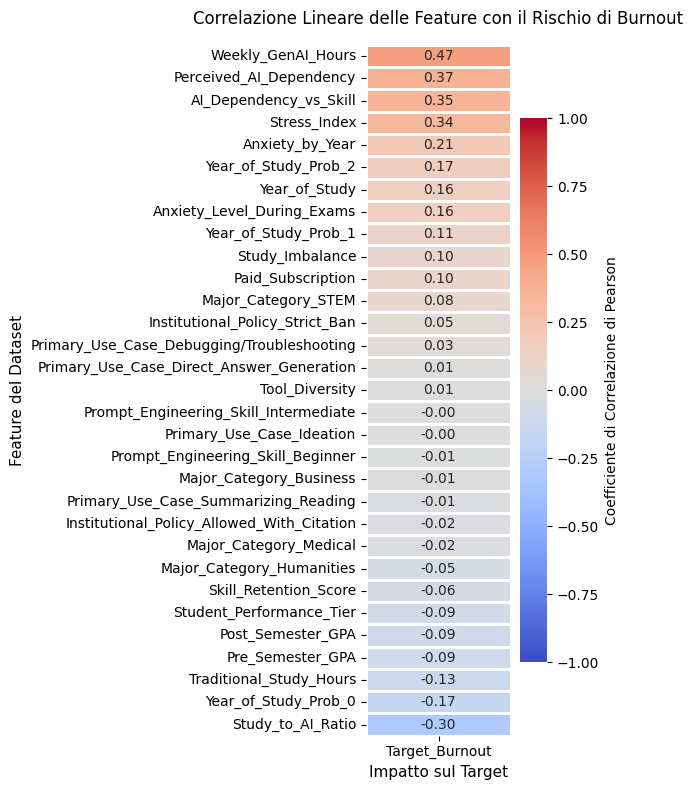

In [120]:

# 1. Creiamo il DataFrame temporaneo unendo Feature e Target
df_corr = X_train.copy()

if y_train.dtype == 'object' or y_train.dtype.name == 'category':
    target_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df_corr['Target_Burnout'] = y_train.map(target_map)
else:
    df_corr['Target_Burnout'] = y_train

# 2. Calcoliamo la matrice ed estraiamo solo la colonna del Target
# Escludiamo l'auto-correlazione del Target con se stesso (che sarebbe 1.0)
correlazione_target = df_corr.corr(method='pearson')[['Target_Burnout']].drop(index='Target_Burnout')

# Ordiniamo i valori in modo decrescente per un impatto visivo immediato
correlazione_target = correlazione_target.sort_values(by='Target_Burnout', ascending=False)

# 3. Disegnamo la heatmap a colonna singola
plt.figure(figsize=(6, 8))
sns.heatmap(
    correlazione_target,
    annot=True,               # Mostra il coefficiente numerico
    fmt=".2f",                # Arrotonda a 2 decimali
    cmap="coolwarm",          # Rosso = aumenta il burnout, Blu = lo diminuisce
    vmin=-1, vmax=1,          # Limiti della scala di correlazione
    linewidths=1,
    cbar_kws={"label": "Coefficiente di Correlazione di Pearson"}
)

# 4. Personalizzazione estetica
plt.title("Correlazione Lineare delle Feature con il Rischio di Burnout", fontsize=12, pad=15)
plt.ylabel("Feature del Dataset", fontsize=11)
plt.xlabel("Impatto sul Target", fontsize=11)

plt.tight_layout()
plt.show()

In [94]:
X_train.describe()

,Major_Category_Business,Major_Category_Humanities,Major_Category_Medical,Major_Category_STEM,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,...,Skill_Retention_Score,Year_of_Study_Prob_0,Year_of_Study_Prob_1,Year_of_Study_Prob_2,Study_to_AI_Ratio,Stress_Index,Anxiety_by_Year,Study_Imbalance,AI_Dependency_vs_Skill,Student_Performance_Tier
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,...,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,0.250925,0.200375,0.129925,0.301200,0.246950,0.126550,0.214200,0.171325,0.370075,0.352500,...,75.760045,0.327375,0.422875,0.249750,2.630978,62.771510,12.234925,8.679086,0.048509,1.000025
std,0.433551,0.400286,0.336225,0.458785,0.431243,0.332472,0.410271,0.376797,0.482831,0.477755,...,13.288228,0.067600,0.011863,0.059900,2.981429,121.457976,8.930097,6.410504,0.030074,0.816543
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,13.230000,0.203356,0.402753,0.179264,0.024390,0.000000,1.000000,0.000000,0.010000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,66.720000,0.292433,0.420467,0.220467,0.709885,5.801660,5.000000,3.760000,0.027221,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,75.970000,0.325282,0.425503,0.242794,1.557515,19.492500,10.000000,7.580000,0.043764,1.000000
75%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,85.170000,0.359065,0.431924,0.272631,3.366081,62.164620,18.000000,12.190000,0.062500,2.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,100.000000,0.417983,0.434936,0.371141,32.899083,2121.000000,50.000000,39.000000,0.544135,2.000000


**fine preparazione colonne**

inizio addestramento del modello (non ho scalato i valori perchè userò un modello di random forest)

In [121]:
print(f"Dimensioni X_train: {X_train.shape}") # controllo la dimensionalità di df
print(f"Dimensioni y_train: {y_train.shape}\n")
print(f"Dimensioni X_test:  {X_test.shape}")
print(f"Dimensioni y_test:  {y_test.shape}")

Dimensioni X_train: (40000, 31)
Dimensioni y_train: (40000,)

Dimensioni X_test:  (10000, 31)
Dimensioni y_test:  (10000,)


In [ ]:

# # Poiché abbiamo un problema a 3 classi (Low, Medium, High), impostiamo l'objective corretto
# xgb_base_vv1 = XGBClassifier(
#     objective='multi:softprob', 
#     random_state=42, 
#     use_label_encoder=False, 
#     eval_metric='mlogloss'
# )

# # 2. Definiamo la griglia degli iperparametri per XGBoost
# # Questa selezione è ottimizzata per trovare un buon bilanciamento senza andare in overfitting
# param_grid = {
#     'n_estimators': [100, 200],          
#     'max_depth': [4, 6, 8],               # Range ideale per catturare non-linearità senza esplodere
#     'learning_rate': [0.02, 0.05, 0.1],   # Inserito 0.02, ottimo per accoppiarsi con più alberi
#     'subsample': [0.7, 0.9],              
#     'colsample_bytree': [0.4, 0.7]       # Percentuale di feature da campionare per ogni albero
# }

# # 3. Configuriama la Grid Search con 5-Fold Cross-Validation
# grid_search_xgb_vv1 = GridSearchCV(
#     estimator=xgb_base_vv1,
#     param_grid=param_grid,
#     cv=5,                                 # Sdoppia il train in 5 parti per convalidare i punteggi
#     scoring='accuracy',                   # Puoi usare 'f1_macro' se le classi sono sbilanciate
#     n_jobs=-1,                            # Sfrutta tutti i core della CPU in parallelo
#     verbose=2                             # Mostra i log dell'avanzamento dei calcoli
# )

# # 4. Avviamo l'addestramento sui dati
# grid_search_xgb_vv1.fit(X_train, y_train)


# print("\n--- Risultati della Grid Search con XGBoost ---")
# print(f"Miglior Accuratezza in Cross-Validation: {grid_search_xgb_vv1.best_score_:.4f}")
# print("Migliori Iperparametri Trovati:")
# for param, value in grid_search_xgb_vv1.best_params_.items():
#     print(f"  -> {param}: {value}")

# # 5. Estraiamo il modello migliore e già pronto
# best_xgb_model_vv1 = grid_search_xgb_vv1.best_estimator_



# addestramento del random forest con gli iperparametri trovati

In [122]:
# 1. Istanziamo il modello con gli iperparametri ottimi trovati
# Aggiungiamo random_state=42 per garantire la riproducibilità dei risultati
best_rf = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=2,
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Sfrutta tutti i core della CPU per velocizzare l'addestramento
)

# 2. Addestriamo il modello sul set di train (che include il tuo Target Encoding)
best_rf.fit(X_train, y_train)

# 3. Valutiamo le performance sul set di test per verificare che non ci sia overfitting
y_pred = best_rf.predict(X_test)

# Stampiamo i risultati finali
print(f"Accuratezza finale sul Test Set: {accuracy_score(y_test, y_pred):.4f}\n")
print("--- Report di Classificazione Completo ---")
print(classification_report(y_test, y_pred))

Accuratezza finale sul Test Set: 0.5282

--- Report di Classificazione Completo ---
              precision    recall  f1-score   support

           0       0.53      0.48      0.50      3274
           1       0.48      0.61      0.54      4229
           2       0.67      0.45      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.51      0.53     10000
weighted avg       0.55      0.53      0.53     10000



**Con un'accuratezza del 53.05% su un problema a tre classi (casuale su tre classi = 33%), il modello ha catturato dei pattern utili, ma i dati mostrano che fa fatica a distinguere nettamente tra le classi adiacenti.**

**burnout High: ha una precision molto alta (66%) ma una recall bassa (45%). Questo significa che quando il modello si sbilancia a dire "Rischio Alto", ci indovina quasi sempre, ma si perde per strada più della metà dei veri casi ad alto rischio**



ricorda il map 
'Low': 0, 'Medium': 1, 'High': 2

In [98]:
lista = y_test.unique()
print(lista)  # l'ordine è corretto !! (controllato)

[1 0 2]


In [123]:

# Disattiviamo i log prolissi di Optuna per pulizia visiva
optuna.logging.set_verbosity(optuna.logging.WARNING)

#  VELOCIZZAZIONE 1: Passiamo a 3 Fold per ridurre il carico del 40%
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("--- 1. OTTIMIZZAZIONE IPERPARAMETRI CON OPTUNA (SMART CONFIG) ---")


# --- STUDIO OPTUNA PER LIGHTGBM ---
def objective_lgb(trial):
    params = {
        "objective": "multiclass",
        "num_class": 3,
        "metric": "multi_logloss",
        "boosting_type": "gbdt",
        #  Limitiamo gli stimatori per non appesantire i calcoli inutilmente
        "n_estimators": trial.suggest_int("n_estimators", 100, 250),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1),
        #  Controllo della complessità: max_depth e num_leaves ridotti evitano alberi mastodontici
        "max_depth": trial.suggest_int("max_depth", 4, 7),
        "num_leaves": trial.suggest_int("num_leaves", 20, 45),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 50),
        #  Subsampling: analizza solo una parte delle righe/colonne per ogni albero, velocizzando il fit
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-1, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-1, 5.0),
        "class_weight": "balanced",  # Fondamentale per la recall delle classi penalizzate
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        scores.append(f1_score(y_va, preds, average="macro"))

    return np.mean(scores)


# --- STUDIO OPTUNA PER XGBOOST ---
def objective_xgb(trial):
    params = {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        #  XGBoost è più pesante, teniamo gli stimatori snelli per il tuning
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1),
        #  Limitando max_depth a un massimo di 5 tagliamo drasticamente i tempi di calcolo
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
        "alpha": trial.suggest_float("alpha", 1e-1, 5.0),
        "lambda": trial.suggest_float("lambda", 1e-1, 5.0),
        "random_state": 42,
        "n_jobs": -1,
    }

    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

        w_train = compute_sample_weight(class_weight="balanced", y=y_tr)

        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, sample_weight=w_train)
        preds = model.predict(X_va)
        scores.append(f1_score(y_va, preds, average="macro"))

    return np.mean(scores)


#  VELOCIZZAZIONE 2: Limitiamo a 10 i trial totali per ciascuno studio
print("Ottimizzazione LightGBM in corso...")
study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(objective_lgb, n_trials=10)
print(f"Miglior Macro F1 LightGBM ottenuto: {study_lgb.best_value:.4f}")

print("\nOttimizzazione XGBoost in corso...")
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=10)
print(f"Miglior Macro F1 XGBoost ottenuto: {study_xgb.best_value:.4f}")


# --- 2. ADDESTRAMENTO FINALE CON I PARAMETRI MIGLIORI ---
print("\n--- 2. TRAINING FINALE SUL TEST SET ---")

# Estrazione e aggiornamento parametri LightGBM
best_params_lgb = study_lgb.best_params
best_params_lgb.update(
    {
        "objective": "multiclass",
        "num_class": 3,
        "metric": "multi_logloss",
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
    }
)

# Estrazione e aggiornamento parametri XGBoost
best_params_xgb = study_xgb.best_params
best_params_xgb.update(
    {
        "objective": "multi:softprob",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": 42,
        "n_jobs": -1,
    }
)

# --- Fit & Predict LightGBM Final ---
print("\n[LightGBM] Addestramento finale in corso...")
final_lgb = lgb.LGBMClassifier(**best_params_lgb)
final_lgb.fit(X_train, y_train)
preds_lgb = final_lgb.predict(X_test)

print("\nReport Dettagliato LightGBM Final:")
print(classification_report(y_test, preds_lgb))

# --- Fit & Predict XGBoost Final ---
print("\n[XGBoost] Addestramento finale in corso...")
final_xgb = xgb.XGBClassifier(**best_params_xgb)
w_train_full = compute_sample_weight(class_weight="balanced", y=y_train)
final_xgb.fit(X_train, y_train, sample_weight=w_train_full)
preds_xgb = final_xgb.predict(X_test)

print("\nReport Dettagliato XGBoost Final:")
print(classification_report(y_test, preds_xgb))

--- 1. OTTIMIZZAZIONE IPERPARAMETRI CON OPTUNA (SMART CONFIG) ---
Ottimizzazione LightGBM in corso...
Miglior Macro F1 LightGBM ottenuto: 0.5227

Ottimizzazione XGBoost in corso...
Miglior Macro F1 XGBoost ottenuto: 0.5237

--- 2. TRAINING FINALE SUL TEST SET ---

[LightGBM] Addestramento finale in corso...

Report Dettagliato LightGBM Final:
              precision    recall  f1-score   support

           0       0.50      0.65      0.57      3274
           1       0.50      0.35      0.41      4229
           2       0.55      0.61      0.58      2497

    accuracy                           0.51     10000
   macro avg       0.52      0.54      0.52     10000
weighted avg       0.51      0.51      0.50     10000


[XGBoost] Addestramento finale in corso...

Report Dettagliato XGBoost Final:
              precision    recall  f1-score   support

           0       0.50      0.65      0.57      3274
           1       0.50      0.35      0.41      4229
           2       0.55      0.6

In [124]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

# 1. Creazione e addestramento dell'Ensemble (LGBM + XGBOOST)
ensemble_model = VotingClassifier(
    estimators=[("lgb", final_lgb), ("xgb", final_xgb)],
    voting="soft"  # Fondamentale per poter usare predict_proba()
)

ensemble_model.fit(X_train, y_train)

# 2. Estrarre le PROBABILITÀ invece delle etichette secche
# Questo restituisce una matrice di float (es. 0.234, 0.512, 0.254)
probs_ensemble = ensemble_model.predict_proba(X_test)

# 3. Trasformiamo le probabilità in un DataFrame con percentuali leggibili
# Recuperiamo l'ordine esatto delle classi dal modello (.classes_)
class_labels = ensemble_model.classes_




df_percentuali = pd.DataFrame(
    probs_ensemble * 100,  # Moltiplichiamo per 100 per avere la scala 0-100%
    columns=[f"Probabilità_{cls}_%" for cls in class_labels],
    index=X_test.index
)

# Aggiungiamo anche la predizione finale del modello e il valore reale per un confronto diretto
df_percentuali["Predizione_Modello"] = ensemble_model.predict(X_test)
df_percentuali["Valore_Reale"] = y_test

# 4. Mostriamo i primi 10 studenti sul terminale
print("\n--- PERCENTUALI DI BURNOUT PER STUDENTE (Primi 10 casi) ---")
print(df_percentuali.head(10).round(2).to_string())



--- PERCENTUALI DI BURNOUT PER STUDENTE (Primi 10 casi) ---
       Probabilità_0_%  Probabilità_1_%  Probabilità_2_%  Predizione_Modello  Valore_Reale
18437            14.11            40.60            45.29                   2             1
5385             39.30            45.44            15.26                   1             1
41097            51.60            37.82            10.58                   0             0
46083            30.49            48.19            21.32                   1             1
46666             1.80            15.76            82.44                   2             2
2939             16.93            47.09            35.98                   1             2
7136              1.49             9.95            88.55                   2             2
38313             2.84            17.91            79.25                   2             2
29535            18.83            34.60            46.57                   2             1
28078            17.74       

In [ ]:
from sklearn.ensemble import VotingClassifier

# 1. Creazione e addestramento dell'Ensemble (LGBM + XGBOOST)
ensemble_model = VotingClassifier(
    estimators=[("lgb", final_lgb), ("xgb", final_xgb)],
    voting="soft"  # Fondamentale per poter usare predict_proba()
)

ensemble_model.fit(X_train, y_train)

# 2. Estrarre le PROBABILITÀ invece delle etichette secche
probs_ensemble = ensemble_model.predict_proba(X_test)

# 3. Trasformiamo le probabilità in un DataFrame con percentuali leggibili
class_labels = ensemble_model.classes_

# Mappiamo dinamicamente i nomi delle colonne in base a come sono ordinate nel modello (0, 1, 2)
df_percentuali = pd.DataFrame(
    probs_ensemble * 100,  # Scala 0-100%
    columns=[f"Probabilità_{cls}_%" for cls in class_labels],
    index=X_test.index
)

# Identifichiamo i nomi esatti delle colonne generate per non fare errori di stringhe
col_low = f"Probabilità_{class_labels[0]}_%"     # Corrisponde a Low
col_medium = f"Probabilità_{class_labels[1]}_%"  # Corrisponde a Medium
col_high = f"Probabilità_{class_labels[2]}_%"    # Corrisponde a High


# 4. APPLICAZIONE DELLA TUA LOGICA SULLA DISTANZA DELLE PROBABILITÀ (< 11%)
def calcola_output_unico(row):
    p_low = row[col_low]
    p_med = row[col_medium]
    p_high = row[col_high]
    
    # REGOLA 1: Controllo sovrapposizione Low e Medium (distanza < 11)
    if abs(p_low - p_med) < 13.0 and p_low > p_high and p_med > p_high:
        return "medio-basso"
        
    # REGOLA 2: Controllo sovrapposizione Medium e High (distanza < 11)
    if abs(p_med - p_high) < 13.0 and p_med > p_low and p_high > p_low:
        return "medio-alto"
        
    # DEFAULT: Se non ci sono sovrapposizioni sotto l'11%, vince la classe con la percentuale massima
    max_idx = np.argmax([p_low, p_med, p_high])
    if max_idx == 0:
        return "basso"
    elif max_idx == 1:
        return "medio"
    else:
        return "alto"

# Creiamo l'UNICA colonna di output finale applicando la funzione
df_percentuali["Predizione_Finale"] = df_percentuali.apply(calcola_output_unico, axis=1)

# Aggiungiamo il valore reale originale per un check visivo immediato di confronto
df_percentuali["Valore_Reale_Originale"] = y_test


# 5. VISUALIZZAZIONE DEI RISULTATI
print("\n--- DATAFRAME FINALE CON OUTPUT UNICO E SFUMATO (Primi 15 casi) ---")
print(df_percentuali.head(15).round(2).to_string())


#                               OUTPUT FINALE   

In [ ]:
import joblib
filename = 'burnout_model.pkl'
joblib.dump(ensemble_model, filename=filename)